In [1]:
import itertools as iter

import awkward as ak

import dask
import dask_awkward as dak
import hist.dask as hda
import matplotlib.pyplot as plt

# import numba
import numpy as np
import uproot

# import vector as vec
from coffea.analysis_tools import PackedSelection
from coffea.nanoevents import NanoEventsFactory, ScoutingNanoAODSchema
# from hist import Hist


In [2]:
from coffea.lookup_tools import extractor
from coffea.jetmet_tools import FactorizedJetCorrector, JetCorrectionUncertainty
from coffea.jetmet_tools import JECStack, CorrectedJetsFactory

In [4]:
file_list = [line.strip('\n') for line in open("filelists/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_0000.txt").readlines()] # + [line.strip('\n') for line in open("filelists/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_0001.txt").readlines()] + [line.strip('\n') for line in open("filelists/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_0002.txt").readlines()]
file_list = ["root://cmseos.fnal.gov//" + string for string in file_list]



ScoutingNanoAODSchema.warn_missing_crossrefs = False

small_events = NanoEventsFactory.from_root(
    {file : "Events" for file in file_list[0:3]},
    schemaclass=ScoutingNanoAODSchema,
    metadata={"dataset": "HadronicTops"},
).events()

events = small_events
#ak.num(small_events, axis=0).compute()

In [5]:
from helper_functions import tri_mds, mass_asymmetry, d_phi, tri_delta, tri_mds63, tri_mds6332

In [6]:
def apply_JEC_MC(ev):
    ext = extractor()
    ext.add_weight_sets(
        [
            "* * corrections/Summer22EE_22Sep2023_V2_MC/Summer22EE_22Sep2023_V2_MC_L1FastJet_AK4PFPuppi.txt",
            "* * corrections/Summer22EE_22Sep2023_V2_MC/Summer22EE_22Sep2023_V2_MC_L2Relative_AK4PFPuppi.txt",
            "* * corrections/Summer22EE_22Sep2023_V2_MC/Summer22EE_22Sep2023_V2_MC_L3Absolute_AK4PFPuppi.txt",
            "* * corrections/Summer22EE_22Sep2023_V2_MC/Summer22EE_22Sep2023_V2_MC_L2L3Residual_AK4PFPuppi.txt",
            #"* * corrections/Summer22EE_22Sep2023_V2_MC/Summer22EE_22Sep2023_V2_MC_Uncertainty_AK4PFPuppi.junc.txt",
        ],
    )
    ext.finalize()

    jec_stack_names = [
        "Summer22EE_22Sep2023_V2_MC_L1FastJet_AK4PFPuppi",
        "Summer22EE_22Sep2023_V2_MC_L2Relative_AK4PFPuppi",
        "Summer22EE_22Sep2023_V2_MC_L3Absolute_AK4PFPuppi",
        "Summer22EE_22Sep2023_V2_MC_L2L3Residual_AK4PFPuppi",
        #"Summer22EE_22Sep2023_V2_MC_Uncertainty_AK4PFPuppi",
    ]

    evaluator = ext.make_evaluator()
    jec_inputs = {name: evaluator[name] for name in jec_stack_names}
    jec_stack = JECStack(jec_inputs)

    name_map = jec_stack.blank_name_map
    name_map["JetPt"] = "pt"
    name_map["JetMass"] = "mass"
    name_map["JetEta"] = "eta"
    name_map["JetA"] = "area"

    jets = ev.ScoutingJet

    jets["pt_raw"] = jets["pt"]
    jets["mass_raw"] = jets["mass"]
    jets["rho"] = ak.broadcast_arrays(ev.ScoutingRho, jets.pt)[0]
    name_map["ptGenJet"] = "pt_gen"
    name_map["ptRaw"] = "pt_raw"
    name_map["massRaw"] = "mass_raw"
    name_map["Rho"] = "rho"

    # corrector = FactorizedJetCorrector(
    #     Summer22EE_22Sep2023_V2_MC_L2Relative_AK4PFPuppi=evaluator["Summer22EE_22Sep2023_V2_MC_L2Relative_AK4PFPuppi"],
    #     Summer22EE_22Sep2023_V2_MC_L1FastJet_AK4PFPuppi=evaluator["Summer22EE_22Sep2023_V2_MC_L1FastJet_AK4PFPuppi"],
    #     Summer22EE_22Sep2023_V2_MC_L2L3Residual_AK4PFPuppi=evaluator["Summer22EE_22Sep2023_V2_MC_L2L3Residual_AK4PFPuppi"],
    #     #Summer22EE_22Sep2023_V2_MC_L2Residual_AK4PFPuppi=evaluator["Summer22EE_22Sep2023_V2_MC_L2Residual_AK4PFPuppi"],
    #     Summer22EE_22Sep2023_V2_MC_L3Absolute_AK4PFPuppi=evaluator["Summer22EE_22Sep2023_V2_MC_L3Absolute_AK4PFPuppi"],
    # )

    # uncertainties = JetCorrectionUncertainty(
    #     Summer22EE_22Sep2023_V2_MC_Uncertainty_AK4PFPuppi=evaluator["Summer22EE_22Sep2023_V2_MC_Uncertainty_AK4PFPuppi"],
    # )

    jet_factory = CorrectedJetsFactory(name_map, jec_stack)


    return jet_factory.build(jets)

def tight_jets(ev,jet_eta_cut: float=2.4, jet_pt_cut: float=30, jec: bool=True):
# changed this to tight_jet or something like that
# clean jet or jet cleaning
    res = ak.copy(ev)
    if jec:
        res["ScoutingJet"] = apply_JEC_MC(res)
    jet_cut = (abs(res.ScoutingJet.eta) < jet_eta_cut) \
          & (res.ScoutingJet.pt > jet_pt_cut) \
          & (res.ScoutingJet.neHEF < 0.90) \
          & (res.ScoutingJet.neEmEF < 0.90) \
          & (res.ScoutingJet.nConstituents > 1) \
          & (res.ScoutingJet.muEmEF < 0.80) \
          & (res.ScoutingJet.chHEF > 0.01) \
          & (res.ScoutingJet.nCh > 0) \
          & (res.ScoutingJet.chEmEF < 0.80)
    res["ScoutingJet"] = res.ScoutingJet[jet_cut]
    return res

def format_trijet_events(ev, jet_eta_cut: float=2.4, jet_pt_cut: float=30, jec: bool=True):

    # sel = PackedSelection()
    # sel.add("SixJets", ak.num(ev.ScoutingJet[ev.ScoutingJet.eta < jet_eta_cut], axis=1) >= 6)

    tight = tight_jets(ev,jet_eta_cut,jet_pt_cut,jec)

    result = tight[ak.num(tight.ScoutingJet,axis=1) >= 6]

    selected_jets = result.ScoutingJet[:,0:6]
    trijet = ak.combinations(selected_jets, 3, fields=["j1","j2","j3"])

    mds_val, m12, m13, m23 = tri_mds(trijet)

    result["Trijet"] = ak.zip(
        {
            "j1": trijet.j1,
            "j2": trijet.j2,
            "j3": trijet.j3,
            "px": trijet.j1.px + trijet.j2.px + trijet.j3.px,
            "py": trijet.j1.py + trijet.j2.py + trijet.j3.py,
            "pz": trijet.j1.pz + trijet.j2.pz + trijet.j3.pz,
            "e": trijet.j1.E + trijet.j2.E + trijet.j3.E,
            "masym": mass_asymmetry(selected_jets,trijet),
            "mds": mds_val,
            "m12": m12,
            "m13": m13,
            "m23": m23,
            "dphi": d_phi(selected_jets,trijet),
            "delta": tri_delta(trijet),
            "mds63": tri_mds63(selected_jets, trijet),
        },
        with_name="Momentum4D",
    )

    result["HT"] = ak.sum(abs(result.ScoutingJet.pt), axis=1)
    result["mds6332"] = tri_mds6332(selected_jets, trijet, mds_val)

    return result

In [7]:
good_events = format_trijet_events(events, jet_eta_cut=2.4,jec=True)
non_jec_events = format_trijet_events(events, jet_eta_cut=2.4,jec=False)

In [8]:
print(ak.sum(ak.num(good_events.Trijet)).compute())
print(ak.sum(ak.num(non_jec_events.Trijet)).compute())

1121620
733160


In [8]:
good_events.ScoutingJet[10].E.compute()

<Array [29.9, 31.2, 46.5, 203, 57.6, 214, 28.8] type='7 * float32'>

In [9]:
non_jec_events.ScoutingJet[10].E.compute()

<Array [72.9, 66.9, 77.5, 268, 61.7, 217, 23.9] type='7 * float32'>

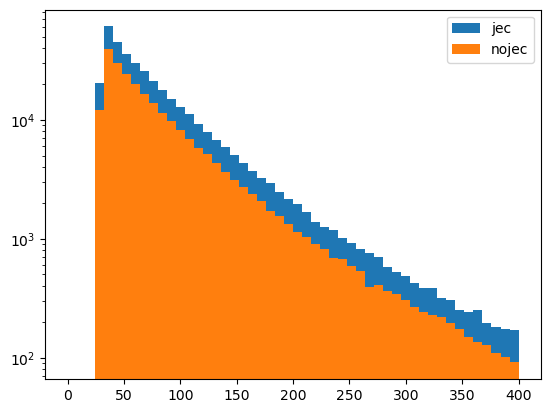

In [14]:
plt.hist(
    ak.flatten(good_events.ScoutingJet.pt).compute(),
    bins=50,
    label="jec",
    range=(0,400),
)

plt.hist(
    ak.flatten(non_jec_events.ScoutingJet.pt).compute(),
    bins=50,
    label="nojec",
    range=(0,400),
)
plt.yscale("log")
plt.legend()

Text(0.5, 0, 'E/E_raw, only L1FastJet_AK4PFPuppi')

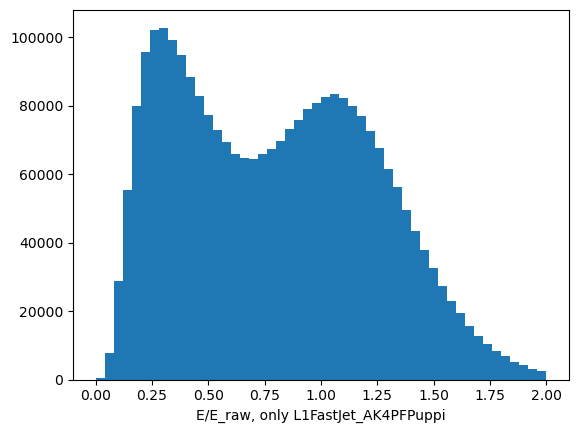

In [11]:
plt.hist(
    ak.flatten(good_events.ScoutingJet.E/non_jec_events.ScoutingJet.E).compute(),
    bins=50,
    range=(0,2),
)

plt.xlabel("E/E_raw, only L1FastJet_AK4PFPuppi")

In [12]:
good_events.Trijet[0].mass.compute()

<Array [115, 151, 153, 124, 101, ..., 61.2, 419, 418, 481] type='20 * float32'>

In [13]:
non_jec_events.Trijet[0].mass.compute()

<Array [255, 313, 277, 229, 204, ..., 89, 572, 517, 598] type='20 * float32'>

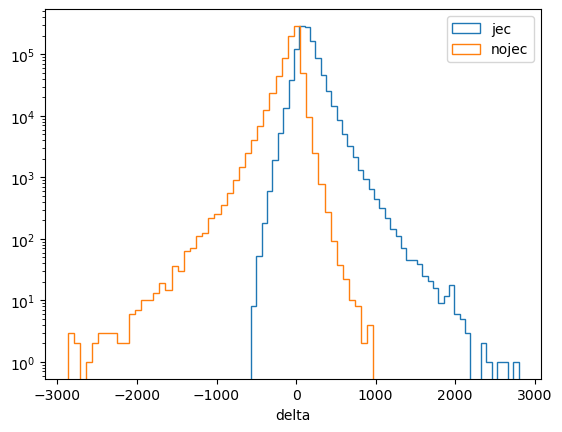

In [13]:
plt.hist(
    ak.flatten(good_events.Trijet.delta).compute(),
    bins= 50,
    label="jec",
    histtype="step",
    )
plt.hist(
    ak.flatten(non_jec_events.Trijet.delta).compute(),
    bins= 50,
    label="nojec",
    histtype="step",
    )

#y axis is in pico-barns, need to multiply by luminosity to get num events
#lum in inverse pico-barns
plt.yscale("log")
plt.xlabel("delta")
plt.legend()

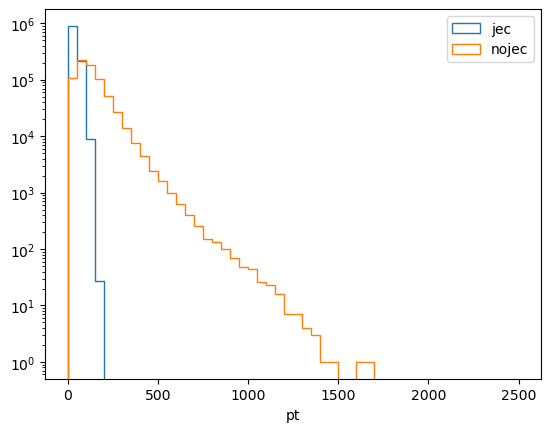

In [15]:
plt.hist(
    ak.flatten(good_events.Trijet.pt).compute(),
    bins= 50,
    label="jec",
    histtype="step",
    range=(0,2500),
    )
plt.hist(
    ak.flatten(non_jec_events.Trijet.pt).compute(),
    bins= 50,
    label="nojec",
    histtype="step",
    range=(0,2500),
    )

#y axis is in pico-barns, need to multiply by luminosity to get num events
#lum in inverse pico-barns
plt.yscale("log")
plt.xlabel("pt")
plt.legend()

In [21]:
h_mass = (
    hda.Hist.new
    .StrCat(["jec","nojec"], growth=True, name="cuts")
    .Reg(1500, 108, 238, name="mass", label="Trijet Invariant Mass")
    .Weight()
)

In [22]:
overallcut = (good_events.HT > 550) & (good_events.mds6332 < 1.25)
cut_events = good_events[overallcut]

cut = (cut_events.Trijet.masym < 0.15) & (cut_events.Trijet.mds < 0.175) & (cut_events.Trijet.delta > 750)
h_mass.fill(mass=ak.flatten(cut_events.Trijet[cut].mass), cuts="jec")

Hist(
  StrCategory(['jec', 'nojec'], growth=True, name='cuts'),
  Regular(1500, 108, 238, name='mass', label='Trijet Invariant Mass'),
  storage=Weight()) # Sum: WeightedSum(value=0, variance=0) (has staged fills)

In [61]:
print(ak.count(ak.flatten(cut_events.Trijet[cut].mass)).compute())
print(ak.count(ak.flatten(good_events.Trijet.mass)).compute())

23279
11424120


In [23]:
overallcut = (non_jec_events.HT > 550) & (non_jec_events.mds6332 < 1.25)
cut_events = non_jec_events[overallcut]

cut = (cut_events.Trijet.masym < 0.15) & (cut_events.Trijet.mds < 0.175) & (cut_events.Trijet.delta > 250)
h_mass.fill(mass=ak.flatten(cut_events.Trijet[cut].mass), cuts="nojec")

Hist(
  StrCategory(['jec', 'nojec'], growth=True, name='cuts'),
  Regular(1500, 108, 238, name='mass', label='Trijet Invariant Mass'),
  storage=Weight()) # Sum: WeightedSum(value=0, variance=0) (has staged fills)

In [63]:
print(ak.count(ak.flatten(cut_events.Trijet[cut].mass)).compute())
print(ak.count(ak.flatten(non_jec_events.Trijet.mass)).compute())

9393
7415540


In [64]:
print('transformed pt ratios', ak.min(good_events["ScoutingJet"].pt/good_events["ScoutingJet"].pt_raw).compute())
print('transformed mass ratios', ak.min(good_events["ScoutingJet"].mass/good_events["ScoutingJet"].mass_raw).compute())

# print('JES UP pt ratio', (good_events["ScoutingJet"].JES_jes.up.pt/good_events["ScoutingJet"].pt_raw).compute())
# print('JES DOWN pt ratio', (good_events["ScoutingJet"].JES_jes.down.pt/good_events["ScoutingJet"].pt_raw).compute())

transformed pt ratios 1.0267797
transformed mass ratios 1.0267797


In [24]:
hist = h_mass.compute()

In [25]:
hd250 = hist[:,::50j]

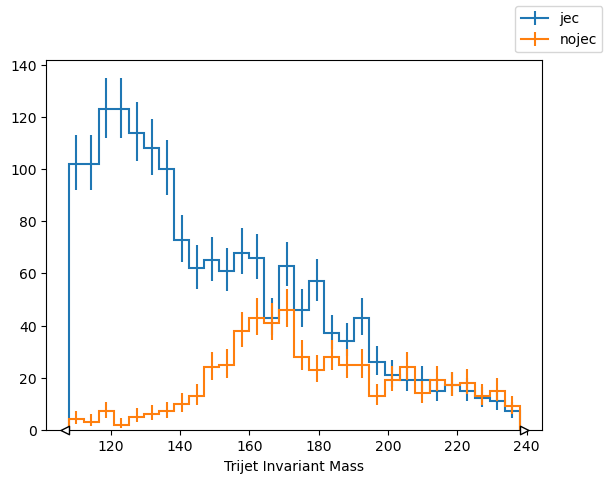

In [26]:
fig, ax = plt.subplots()
hd250.plot1d(ax=ax)
# ax.set_yscale("log")
fig.legend()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fea1dfc1030>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

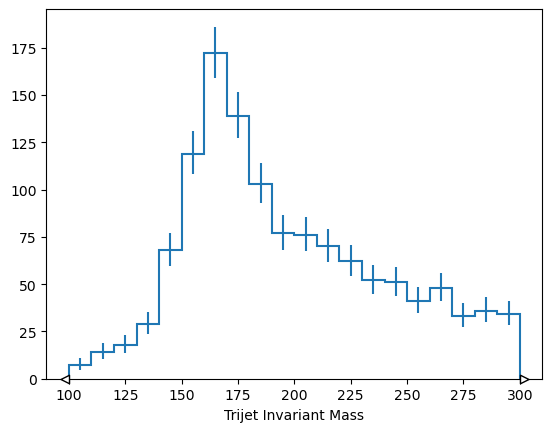

In [ ]:
fig, ax = plt.subplots()
hd250.plot1d(ax=ax)
# ax.set_yscale("log")


In [33]:
h_mass = (
    hda.Hist.new
    .StrCat(["Full","CutNoDelta","DeltaGr250","DeltaGr0","DeltaGr125","MinAsy"], growth=True, name="cuts")
    .Reg(1000, 100, 300, name="mass", label="Trijet Invariant Mass")
    .Weight()
)

h_HT = (
    hda.Hist.new
    .StrCat(["Full","CutNoDelta","DeltaGr250","DeltaGr0","DeltaGr125","MinAsy"], growth=True, name="cuts")
    .Reg(1000, 0, 3000, name="ht", label="Scalar Sum of Hadronic Transverse Energy")
    .Weight()
)

h_delta = (
    hda.Hist.new
    .StrCat(["Full","CutNoDelta","DeltaGr250","DeltaGr0","DeltaGr125","MinAsy"], growth=True, name="cuts")
    .Reg(1000, -1500, 1500, name="delta", label="Trijet Delta")
    .Weight()
)

h_lead_pt = (
    hda.Hist.new
    .StrCat(["Full","CutNoDelta","DeltaGr250","DeltaGr0","DeltaGr125","MinAsy"], growth=True, name="cuts")
    .Reg(1000, 0, 3000, name="pt", label="Leading Jet Pt")
    .Weight()
)

In [34]:
h_mass.fill(mass=ak.flatten(good_events.Trijet.mass), cuts="Full")
h_HT.fill(ht=good_events.HT, cuts="Full")
h_delta.fill(delta=ak.flatten(good_events.Trijet.delta,axis=1), cuts="Full")
h_lead_pt.fill(pt=good_events.ScoutingJet[:,0].pt, cuts="Full")

overallcut = (good_events.HT > 550) & (good_events.mds6332 < 1.25)
cut_events = good_events[overallcut]

cut = (cut_events.Trijet.masym < 0.15) & (cut_events.Trijet.mds < 0.175)
h_mass.fill(mass=ak.flatten(cut_events.Trijet[cut].mass), cuts="CutNoDelta")
h_HT.fill(ht=cut_events.HT, cuts="CutNoDelta")
h_delta.fill(delta=ak.flatten(cut_events.Trijet[cut].delta,axis=1), cuts="CutNoDelta")
h_lead_pt.fill(pt=cut_events.ScoutingJet[:,0].pt, cuts="CutNoDelta")

cut = (cut_events.Trijet.masym < 0.15) & (cut_events.Trijet.mds < 0.175) & (cut_events.Trijet.delta > 0)
h_mass.fill(mass=ak.flatten(cut_events.Trijet[cut].mass), cuts="DeltaGr0")
h_HT.fill(ht=cut_events.HT, cuts="DeltaGr0")
h_delta.fill(delta=ak.flatten(cut_events.Trijet[cut].delta,axis=1), cuts="DeltaGr0")
h_lead_pt.fill(pt=cut_events.ScoutingJet[:,0].pt, cuts="DeltaGr0")

cut = (cut_events.Trijet.masym < 0.15) & (cut_events.Trijet.mds < 0.175) & (cut_events.Trijet.delta > 125)
h_mass.fill(mass=ak.flatten(cut_events.Trijet[cut].mass), cuts="DeltaGr125")
h_HT.fill(ht=cut_events.HT, cuts="DeltaGr125")
h_delta.fill(delta=ak.flatten(cut_events.Trijet[cut].delta,axis=1), cuts="DeltaGr125")
h_lead_pt.fill(pt=cut_events.ScoutingJet[:,0].pt, cuts="DeltaGr125")

cut = (cut_events.Trijet.masym < 0.15) & (cut_events.Trijet.mds < 0.175) & (cut_events.Trijet.delta > 250)
h_mass.fill(mass=ak.flatten(cut_events.Trijet[cut].mass), cuts="DeltaGr250")
h_HT.fill(ht=cut_events.HT, cuts="DeltaGr250")
h_delta.fill(delta=ak.flatten(cut_events.Trijet[cut].delta,axis=1), cuts="DeltaGr250")
h_lead_pt.fill(pt=cut_events.ScoutingJet[:,0].pt, cuts="DeltaGr250")

cut_events = good_events #[overallcut]
cut = ak.argmin(cut_events.Trijet.masym,axis=1,keepdims=True)
h_mass.fill(mass=ak.flatten(cut_events.Trijet[cut].mass), cuts="MinAsy")
h_HT.fill(ht=cut_events.HT, cuts="MinAsy")
h_delta.fill(delta=ak.flatten(cut_events.Trijet[cut].delta,axis=1), cuts="MinAsy")
h_lead_pt.fill(pt=cut_events.ScoutingJet[:,0].pt, cuts="MinAsy")

Hist(
  StrCategory(['Full', 'CutNoDelta', 'DeltaGr250', 'DeltaGr0', 'DeltaGr125', 'MinAsy'], growth=True, name='cuts'),
  Regular(1000, 0, 3000, name='pt', label='Leading Jet Pt'),
  storage=Weight()) # Sum: WeightedSum(value=0, variance=0) (has staged fills)

In [35]:
hist = h_mass.compute()

In [36]:
hd250 = hist["DeltaGr250",:]
hd250 = hd250[::50j]

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fea1dfc1030>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

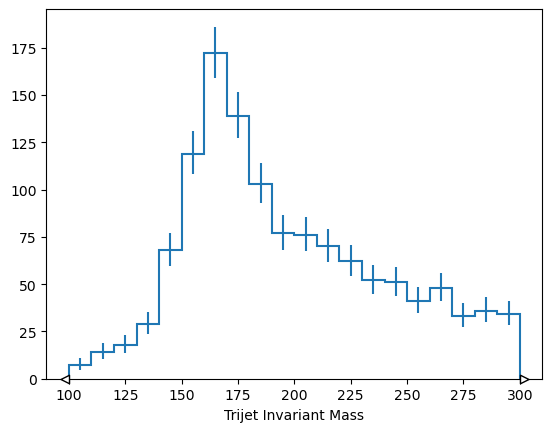

In [38]:
fig, ax = plt.subplots()
hd250.plot1d(ax=ax)
# ax.set_yscale("log")


hist_HT = h_HT.compute()

In [13]:
hhtd250 = hist_HT["DeltaGr250",:]
hhtd250 = hhtd250[::5j]

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f2307de0b80>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

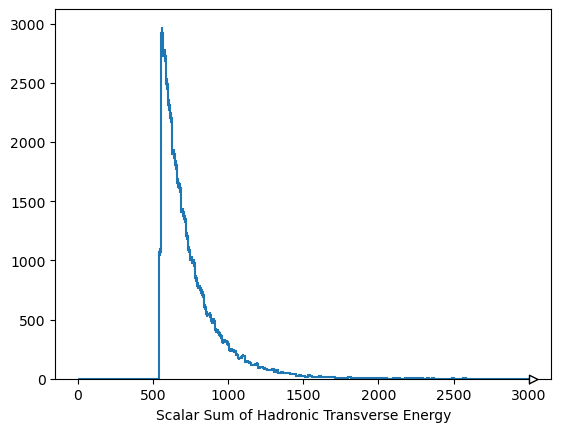

In [14]:
hhtd250.plot1d()